In [1]:
import numpy as np
import torch
from os.path import join
import pandas as pd

In [2]:
dataset = 'section2'
data_path = f'/home/lqr/CLIMA/datasets/{dataset}/processed_data'
data = np.load(join(data_path, 'data.npz'))
gene_sc = data['arr_0'].squeeze(0)
gene_st = data['arr_1'].squeeze(0)
img_st = data['arr_3'].squeeze(0)
gene_sc_tensor = torch.tensor(gene_sc, dtype=torch.float32, device='cuda:0')
gene_st_tensor = torch.tensor(gene_st, dtype=torch.float32, device='cuda:0')
img_st_tensor = torch.tensor(img_st, dtype=torch.float32, device='cuda:0')
# gene_sc = torch.tensor(gene_sc, dtype=torch.float32, device='cuda:0')
# gene_st = torch.tensor(gene_st, dtype=torch.float32, device='cuda:0')

In [3]:
print(gene_sc.shape)
print(gene_st.shape)

(1289, 6025)
(3366, 6025)


**************************************************
S: torch.Size([1289, 6025, 1])
G: torch.Size([3366, 6025, 1])


100%|██████████| 500/500 [00:04<00:00, 108.68it/s]


Epoch 500: Loss -1.415634036064148
[[ 0.43464196  0.10546076  0.22844686 ...  1.4000831   1.5986384
   1.6101958 ]
 [ 1.2835585   1.3111007   1.3179965  ...  1.9340477   1.4359865
   1.3831488 ]
 [ 1.1125393   1.0770786   1.099893   ...  1.5916098   1.0401722
   1.128475  ]
 ...
 [ 2.3687322   2.3902078   2.3972495  ... -2.7054136   0.76601374
   0.92659765]
 [ 2.462157    2.4659133   2.4728308  ...  2.0973394   1.3684721
   1.5407853 ]
 [ 2.2349129   2.2294412   2.2280045  ... -2.4466095  -0.4033273
   0.2956997 ]]


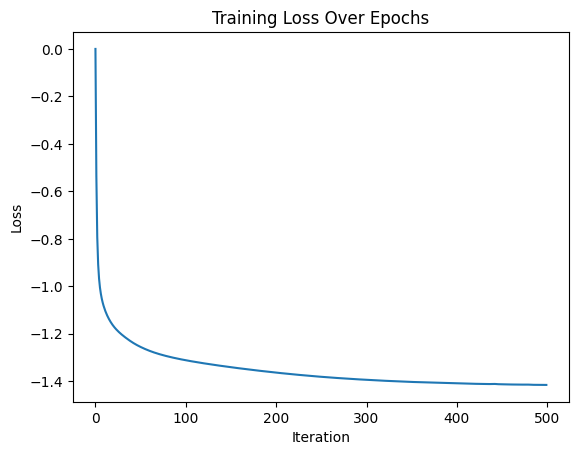

In [4]:
# 用cosine_similarity驱动的tangram进行计算
import cos_tg.train_tangram as tg_cos

# tangram
cos_sim_tg, _ = tg_cos.read_csv_and_run_tangram(
    [gene_sc_tensor],
    [gene_st_tensor],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [5]:
torch.save(torch.tensor(cos_sim_tg, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_org_cos_tg.pt')

In [6]:
# tangram CCA 会出现nan
# import sim_tangram.train_tangram as tg_cca
# # tangram
# cca_tg_sim, _ = tg_cca.read_csv_and_run_tangram(
#     [gene_sc_tensor],
#     [gene_st_tensor],
#     num_epochs=500,
#     print_interval=1,
#     lambda_g1=1,
#     lambda_g2=1,
# )

In [7]:
# 对每一行应用softmax转换为概率分布
tg = torch.tensor(cos_sim_tg, dtype=torch.float32)
# 对每一行应用softmax得到概率分布
prob = torch.softmax(tg, dim=1)

# 获取每行的最大概率值
max_probs = prob.max(dim=1)[0]

# 找到概率值前50%的索引
k = len(max_probs) // 2  # 取50%
top_indices = torch.argsort(max_probs, descending=True)[:k]

# 获取这些高置信度的mapping
confident_mappings = torch.argmax(tg[top_indices], dim=1)


In [8]:
print(cos_sim_tg.shape)
print(confident_mappings.shape)
print(top_indices.shape)
# confident_mappings
# top_indices



(1289, 3366)
torch.Size([644])
torch.Size([644])


In [9]:
from sklearn.decomposition import PCA
import phenograph

sc_conf = gene_sc[top_indices]
st_conf = gene_st[confident_mappings]
img_conf = img_st[confident_mappings]
latent_dim = 100
view_gene_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(sc_conf)
view_peak_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(st_conf)
view_img_feature = PCA(n_components=latent_dim, random_state=42).fit_transform(img_conf)
view_gene_label, _, _ = phenograph.cluster(view_gene_feature, random_state=42)
view_peak_label, _, _ = phenograph.cluster(view_peak_feature, random_state=42)
view_img_label, _, _ = phenograph.cluster(view_img_feature, random_state=42)

Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.13063597679138184 seconds
Jaccard graph constructed in 0.3711545467376709 seconds
Wrote graph to binary file in 0.002977609634399414 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.712042
Louvain completed 21 runs in 0.8207993507385254 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.69158935546875 seconds
Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 0.06639599800109863 seconds
Jaccard graph constructed in 0.3743555545806885 seconds
Wrote graph to binary file in 0.0024929046630859375 seconds
Running Louvain modularity optimization
After 1 runs, maximum modularity is Q = 0.895388
Louvain completed 21 runs in 0.7896513938903809 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 1.593506097793579 seconds
Finding 30 nearest neighbors using minkowski

In [28]:
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(sc_conf, st_conf)
cos_mapping = cos.argmax(axis=1)
print(cos_mapping.shape)
sample_size = cos.shape[0]
print(sample_size)
gt = np.array(range(sample_size))
cos_acc = np.sum(cos_mapping == gt) / sample_size
print("cosine accuracy:", cos_acc)

(644,)
644
cosine accuracy: 0.015527950310559006


In [10]:
print(sc_conf.shape)
print(st_conf.shape)
print(view_gene_label.shape)
print(view_peak_label.shape)

(644, 6025)
(644, 6025)
(644,)
(644,)


In [11]:
import multi_muse_sc as muse

outputs = muse.dual_muse_fit_predict(
    [sc_conf],
    [st_conf, img_conf],
    [view_gene_label],
    [view_peak_label, view_img_label],
    latent_dim=100,
    n_epochs=500,
    info_nce_lambda=10,
    weight_penalty=1,
    triplet_lambda=10,
    # info_nce_lambda_st=0,
)

++++++++++ DualMUSE for multi-modality single-cell analysis ++++++++++
#epoch: 0/200 	 total loss: 602.06 	 sc loss: 177.53 	 st loss: 309.13 	 infoNCE: 115.40 	 sc recon: 77.95 	 st recon: 155.73 	 sc sparse: 99.57 	 st sparse: 140.92 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 12.48
#epoch: 25/200 	 total loss: 457.64 	 sc loss: 169.18 	 st loss: 260.05 	 infoNCE: 28.41 	 sc recon: 71.55 	 st recon: 115.51 	 sc sparse: 97.62 	 st sparse: 138.24 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 6.30
#epoch: 50/200 	 total loss: 436.21 	 sc loss: 166.13 	 st loss: 242.61 	 infoNCE: 27.47 	 sc recon: 70.43 	 st recon: 101.13 	 sc sparse: 95.69 	 st sparse: 135.58 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st infoNCE: 5.90
#epoch: 75/200 	 total loss: 411.38 	 sc loss: 163.61 	 st loss: 220.51 	 infoNCE: 27.26 	 sc recon: 69.82 	 st recon: 81.75 	 sc sparse: 93.79 	 st sparse: 132.94 	 sc trip: 0.00 	 st trip: 0.00 	 sc infoNCE: 0.00 	 st inf

In [12]:
model = outputs[6]

from multi_muse_sc import *

with torch.no_grad():
    data_inputs_tensor_sc = get_all_tensor(
        [gene_sc]
    )
    data_inputs_tensor_st = get_all_tensor(
        [gene_st, img_st]
    )
    out = model(
        data_inputs_tensor_sc,
        data_inputs_tensor_st,
        info_nce_lambda=0,
    )

In [20]:
sc_gene_hat = out[1][0][0]
st_gene_hat = out[1][1][0]
latent_sc = out[0][0]
latent_st = out[0][1]
sc_gene_encode = out[2][0][0]
st_gene_encode = out[2][1][0]
st_img_encode = out[2][1][1]
print(latent_sc.shape)
print(latent_st.shape)
print(sc_gene_hat.shape)
print(st_gene_hat.shape)
print(sc_gene_encode.shape)
print(st_gene_encode.shape)
print(st_img_encode.shape)

torch.Size([1289, 100])
torch.Size([3366, 100])
torch.Size([1289, 6025])
torch.Size([3366, 6025])
torch.Size([1289, 128])
torch.Size([3366, 128])
torch.Size([3366, 128])


**************************************************
S: torch.Size([1289, 6025, 1])
G: torch.Size([3366, 6025, 1])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:04<00:00, 110.75it/s]


Epoch 500: Loss -0.9052006006240845
[[ 0.39852437  1.8863587   0.13446027 ...  2.9337852   3.511687
  -1.8018037 ]
 [-1.6360784  -0.9216985  -3.000418   ... -0.8520856  -0.47361818
  -2.4757795 ]
 [ 2.123856    0.5793437  -0.8354565  ...  0.58133274  0.5392939
   0.6197867 ]
 ...
 [-0.6535366  -2.0939298  -2.7541463  ... -0.857031   -3.1755373
  -1.1410865 ]
 [-1.7751585  -1.089304   -2.251005   ...  0.24885206 -0.54440826
  -1.7971627 ]
 [ 4.8759146   0.17266871  7.0322576  ...  2.7754416  -1.2767197
   0.5777574 ]]


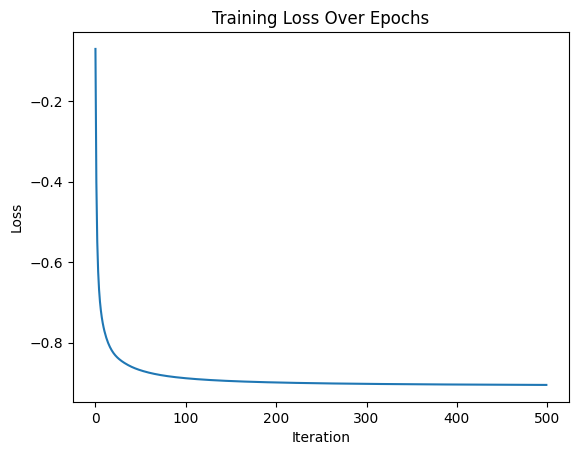

In [14]:
# tangram
confident_tg, _ = tg_cos.read_csv_and_run_tangram(
    [sc_gene_hat],
    [st_gene_hat],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [24]:
from sklearn.metrics.pairwise import cosine_similarity
cos = cosine_similarity(latent_sc.cpu().numpy(), latent_st.cpu().numpy())

**************************************************
S: torch.Size([1289, 128, 1])
G: torch.Size([3366, 128, 2])


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:01<00:00, 278.97it/s]


Epoch 500: Loss -1.1096491813659668
[[ 3.8861811e-01  4.0741915e-01  6.8533912e+00 ...  2.2851889e+00
   3.1686723e-01 -2.5008283e+00]
 [-1.5697396e+00 -1.4558392e+00 -3.3597453e+00 ... -1.4709243e+00
  -2.6250042e-03  2.9842398e+00]
 [-1.7635676e+00 -1.9431980e+00 -3.1987047e+00 ... -2.4750550e+00
   5.3859906e+00  5.2582097e-01]
 ...
 [-1.7484124e+00 -2.5889819e+00 -2.7566986e+00 ... -1.6772299e+00
  -2.2345150e+00 -1.1763349e+00]
 [ 7.1109619e+00  2.4263053e+00  6.8194714e+00 ... -1.5175811e+00
   4.1349927e-01 -1.9171218e+00]
 [-6.6068685e-01 -2.4900200e+00  1.2418317e+00 ... -1.0315628e+00
  -1.4824419e+00  2.0648823e+00]]


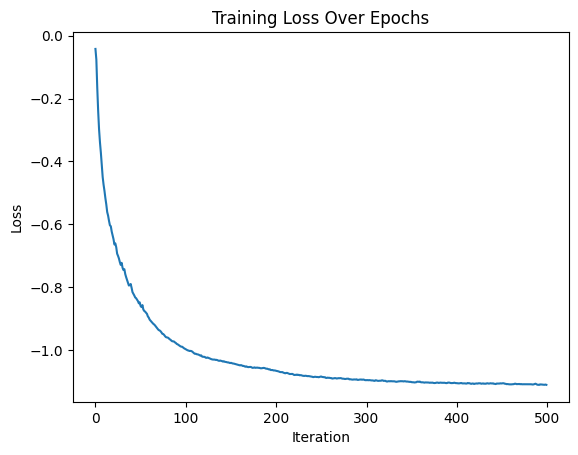

In [21]:
import sim_tangram.train_tangram as tg_cca

cca_tg, _ = tg_cca.read_csv_and_run_tangram(
    [sc_gene_encode],
    [st_gene_encode, st_img_encode],
    num_epochs=500,
    print_interval=500,
    lambda_g1=1,
    lambda_g2=1,
)

In [22]:
torch.save(torch.tensor(confident_tg, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_conf_tg.pt')
torch.save(torch.tensor(cca_tg, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_conf_tg_cca_encode.pt')

In [25]:
torch.save(torch.tensor(cos, dtype=torch.float32), f'/home/lqr/CLIMA/code/pretrained_weights/{dataset}_conf_cos.pt')
